In [1]:
# ============================================================
# PHASE 1 — Data Preparation & Merging
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load datasets ─────────────────────────────────────────
fg = pd.read_csv('fear_greed_index.csv')
hd = pd.read_csv('historical_data.csv')

print("Fear/Greed shape:", fg.shape)
print("Trader data shape:", hd.shape)

# ── 2. Clean Fear/Greed ──────────────────────────────────────
fg['date'] = pd.to_datetime(fg['date'])
fg = fg[['date', 'value', 'classification']].rename(columns={
    'value': 'sentiment_score',
    'classification': 'sentiment'
})
print("\nFear/Greed date range:", fg['date'].min(), "to", fg['date'].max())

# ── 3. Clean Trader Data ─────────────────────────────────────
# Parse timestamp — format is DD-MM-YYYY HH:MM
hd['datetime'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M')
hd['date'] = hd['datetime'].dt.date
hd['date'] = pd.to_datetime(hd['date'])

print("Trader date range:", hd['date'].min(), "to", hd['date'].max())

# ── 4. Merge on date ─────────────────────────────────────────
merged = hd.merge(fg, on='date', how='left')
print("\nMerged shape:", merged.shape)
print("Sentiment nulls after merge:", merged['sentiment'].isnull().sum())

# ── 5. Create useful derived columns ─────────────────────────
# Only closing trades have real PnL
close_trades = merged[merged['Direction'].isin(['Close Long', 'Close Short'])].copy()

# Win / Loss / Breakeven flag
def pnl_flag(x):
    if x > 0:   return 'Win'
    elif x < 0: return 'Loss'
    else:       return 'Breakeven'

close_trades['outcome'] = close_trades['Closed PnL'].apply(pnl_flag)

# Net PnL after fees
close_trades['net_pnl'] = close_trades['Closed PnL'] - close_trades['Fee']

# Trade direction label
close_trades['trade_type'] = close_trades['Direction'].map({
    'Close Long': 'Long',
    'Close Short': 'Short'
})

print("\n── Close trades only ──")
print("Shape:", close_trades.shape)
print("\nOutcome counts:\n", close_trades['outcome'].value_counts())
print("\nSentiment distribution in close trades:\n", close_trades['sentiment'].value_counts())
print("\nSample merged row:")
print(close_trades[['Account','Coin','Direction','Closed PnL','net_pnl','outcome','sentiment','sentiment_score']].head(3).to_string())

Fear/Greed shape: (2644, 4)
Trader data shape: (211224, 16)

Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trader date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00

Merged shape: (211224, 20)
Sentiment nulls after merge: 6

── Close trades only ──
Shape: (84691, 23)

Outcome counts:
 outcome
Win          70754
Loss         13872
Breakeven       65
Name: count, dtype: int64

Sentiment distribution in close trades:
 sentiment
Fear             26481
Greed            19320
Neutral          15843
Extreme Greed    13683
Extreme Fear      9358
Name: count, dtype: int64

Sample merged row:
                                        Account  Coin   Direction  Closed PnL     net_pnl outcome      sentiment  sentiment_score
142  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  AAVE  Close Long  139.418262  138.163862     Win  Extreme Greed             76.0
143  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  AAVE  Close Long   81.421585   80.687508     Win  Extreme Greed             7

=== SENTIMENT VS PERFORMANCE SUMMARY ===
               Avg Net PnL ($)  Median Net PnL ($)  Win Rate (%)  Volume (M USD)
sentiment                                                                       
Extreme Fear             93.99                7.75         79.96           55.03
Fear                    124.69                6.69         88.59          234.56
Neutral                  66.98                4.24         83.00           96.82
Greed                    67.71                3.68         76.08          127.79
Extreme Greed            45.36                6.94         87.39           47.73


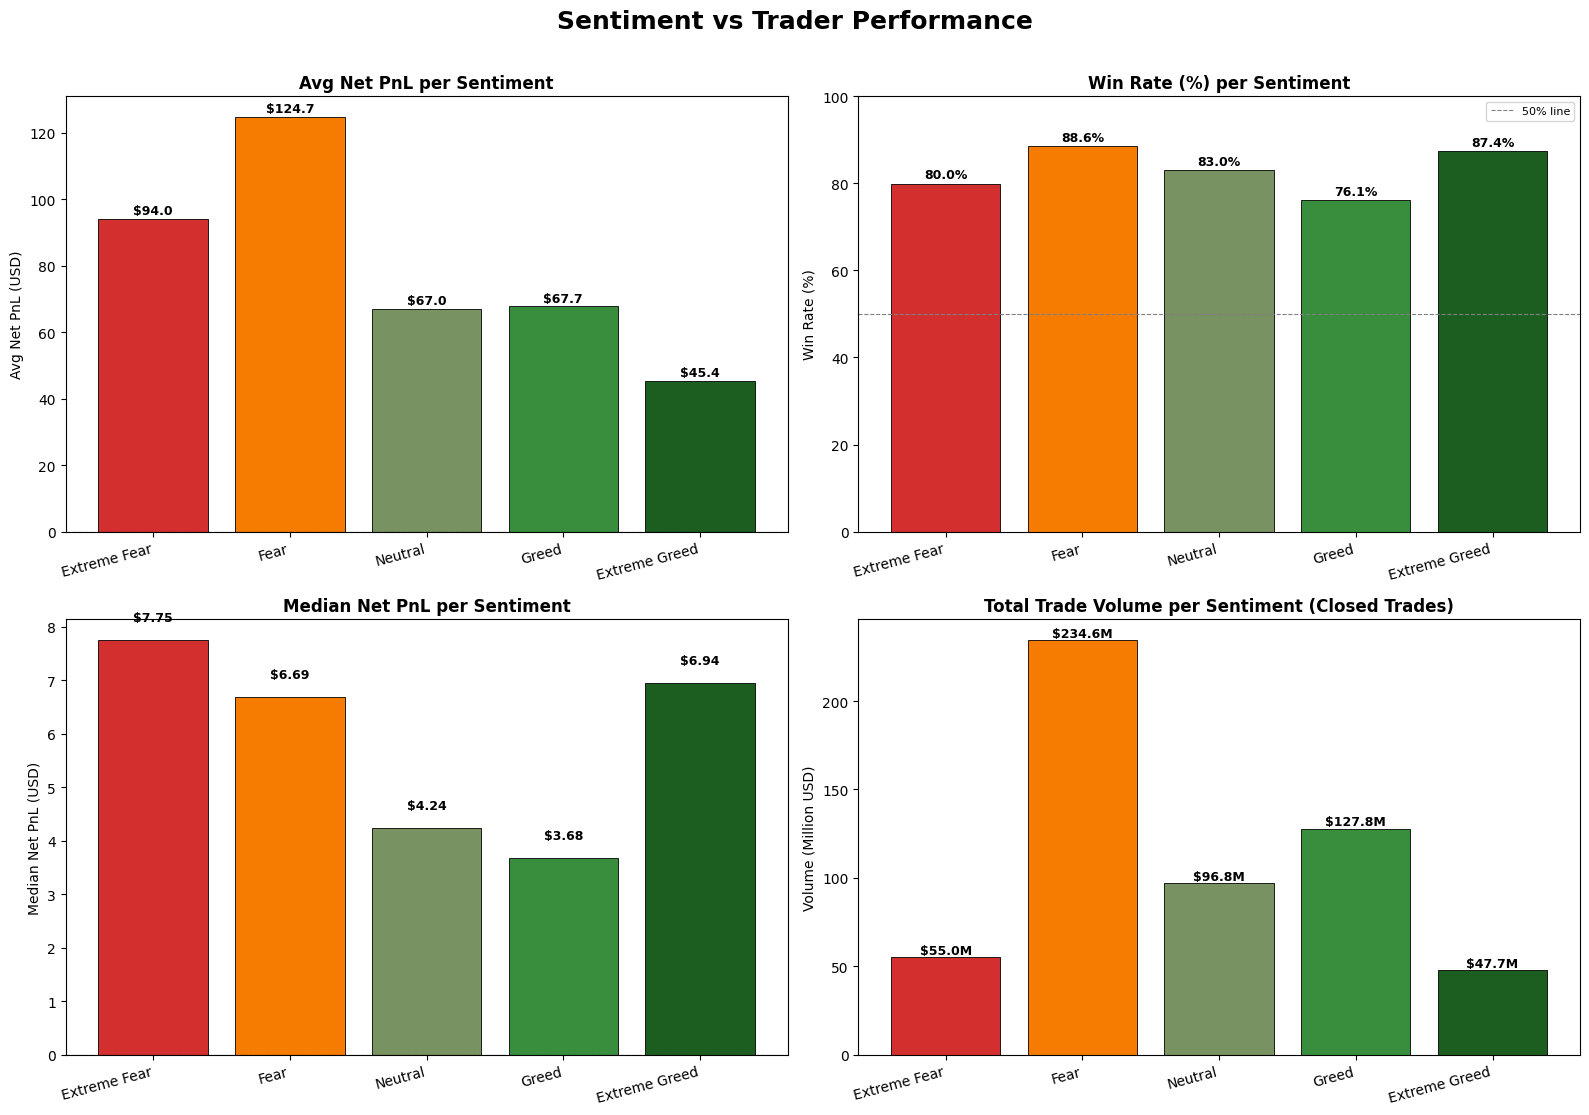


Plot saved as phase2_sentiment_performance.png


In [2]:
# ============================================================
# PHASE 2 — Sentiment vs Trader Performance
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Sentiment order for all plots
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = {
    'Extreme Fear': '#d32f2f',
    'Fear':         '#f57c00',
    'Neutral':      '#789262',
    'Greed':        '#388e3c',
    'Extreme Greed':'#1b5e20'
}

# ── 2.1 Avg Net PnL per Sentiment ────────────────────────────
avg_pnl = (close_trades.groupby('sentiment')['net_pnl']
           .mean()
           .reindex(sentiment_order))

# ── 2.2 Win Rate per Sentiment ───────────────────────────────
win_rate = (close_trades.groupby('sentiment')
            .apply(lambda x: (x['outcome'] == 'Win').sum() / len(x) * 100)
            .reindex(sentiment_order))

# ── 2.3 Median Net PnL per Sentiment ─────────────────────────
median_pnl = (close_trades.groupby('sentiment')['net_pnl']
              .median()
              .reindex(sentiment_order))

# ── 2.4 Total Volume (Size USD) per Sentiment ────────────────
total_vol = (close_trades.groupby('sentiment')['Size USD']
             .sum()
             .reindex(sentiment_order) / 1e6)  # in millions

# ── Print Summary Table ───────────────────────────────────────
summary = pd.DataFrame({
    'Avg Net PnL ($)':    avg_pnl.round(2),
    'Median Net PnL ($)': median_pnl.round(2),
    'Win Rate (%)':       win_rate.round(2),
    'Volume (M USD)':     total_vol.round(2)
})
print("=== SENTIMENT VS PERFORMANCE SUMMARY ===")
print(summary.to_string())

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Sentiment vs Trader Performance', fontsize=18, fontweight='bold', y=1.01)

bar_colors = [colors[s] for s in sentiment_order]

# Plot 1 — Avg Net PnL
ax1 = axes[0, 0]
bars = ax1.bar(sentiment_order, avg_pnl.values, color=bar_colors, edgecolor='black', linewidth=0.6)
ax1.set_title('Avg Net PnL per Sentiment', fontweight='bold')
ax1.set_ylabel('Avg Net PnL (USD)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticklabels(sentiment_order, rotation=15, ha='right')
for bar, val in zip(bars, avg_pnl.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2 — Win Rate
ax2 = axes[0, 1]
bars2 = ax2.bar(sentiment_order, win_rate.values, color=bar_colors, edgecolor='black', linewidth=0.6)
ax2.set_title('Win Rate (%) per Sentiment', fontweight='bold')
ax2.set_ylabel('Win Rate (%)')
ax2.set_ylim(0, 100)
ax2.axhline(50, color='gray', linewidth=0.8, linestyle='--', label='50% line')
ax2.set_xticklabels(sentiment_order, rotation=15, ha='right')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, win_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3 — Median Net PnL
ax3 = axes[1, 0]
bars3 = ax3.bar(sentiment_order, median_pnl.values, color=bar_colors, edgecolor='black', linewidth=0.6)
ax3.set_title('Median Net PnL per Sentiment', fontweight='bold')
ax3.set_ylabel('Median Net PnL (USD)')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_xticklabels(sentiment_order, rotation=15, ha='right')
for bar, val in zip(bars3, median_pnl.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4 — Trade Volume
ax4 = axes[1, 1]
bars4 = ax4.bar(sentiment_order, total_vol.values, color=bar_colors, edgecolor='black', linewidth=0.6)
ax4.set_title('Total Trade Volume per Sentiment (Closed Trades)', fontweight='bold')
ax4.set_ylabel('Volume (Million USD)')
ax4.set_xticklabels(sentiment_order, rotation=15, ha='right')
for bar, val in zip(bars4, total_vol.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'${val:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('phase2_sentiment_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as phase2_sentiment_performance.png")

=== LONG vs SHORT RATIO PER SENTIMENT ===
trade_type      Long  Short  Total  Long %  Short %
sentiment                                          
Extreme Fear    6241   3117   9358   66.69    33.31
Fear           17260   9221  26481   65.18    34.82
Neutral         9993   5850  15843   63.08    36.92
Greed           7998  11322  19320   41.40    58.60
Extreme Greed   7186   6497  13683   52.52    47.48

=== AVG NET PnL BY TRADE TYPE PER SENTIMENT ===
trade_type      Long   Short
sentiment                   
Extreme Fear   79.70  122.60
Fear           81.26  205.98
Neutral        51.24   93.87
Greed          86.91   54.14
Extreme Greed  60.84   28.23

=== WIN RATE BY TRADE TYPE PER SENTIMENT ===
trade_type      Long  Short
sentiment                  
Extreme Fear   84.65  70.58
Fear           89.89  86.16
Neutral        86.13  77.66
Greed          86.30  68.86
Extreme Greed  88.77  85.86

=== AVG TRADE SIZE (USD) PER SENTIMENT ===
sentiment
Extreme Fear     5880.46
Fear             8857

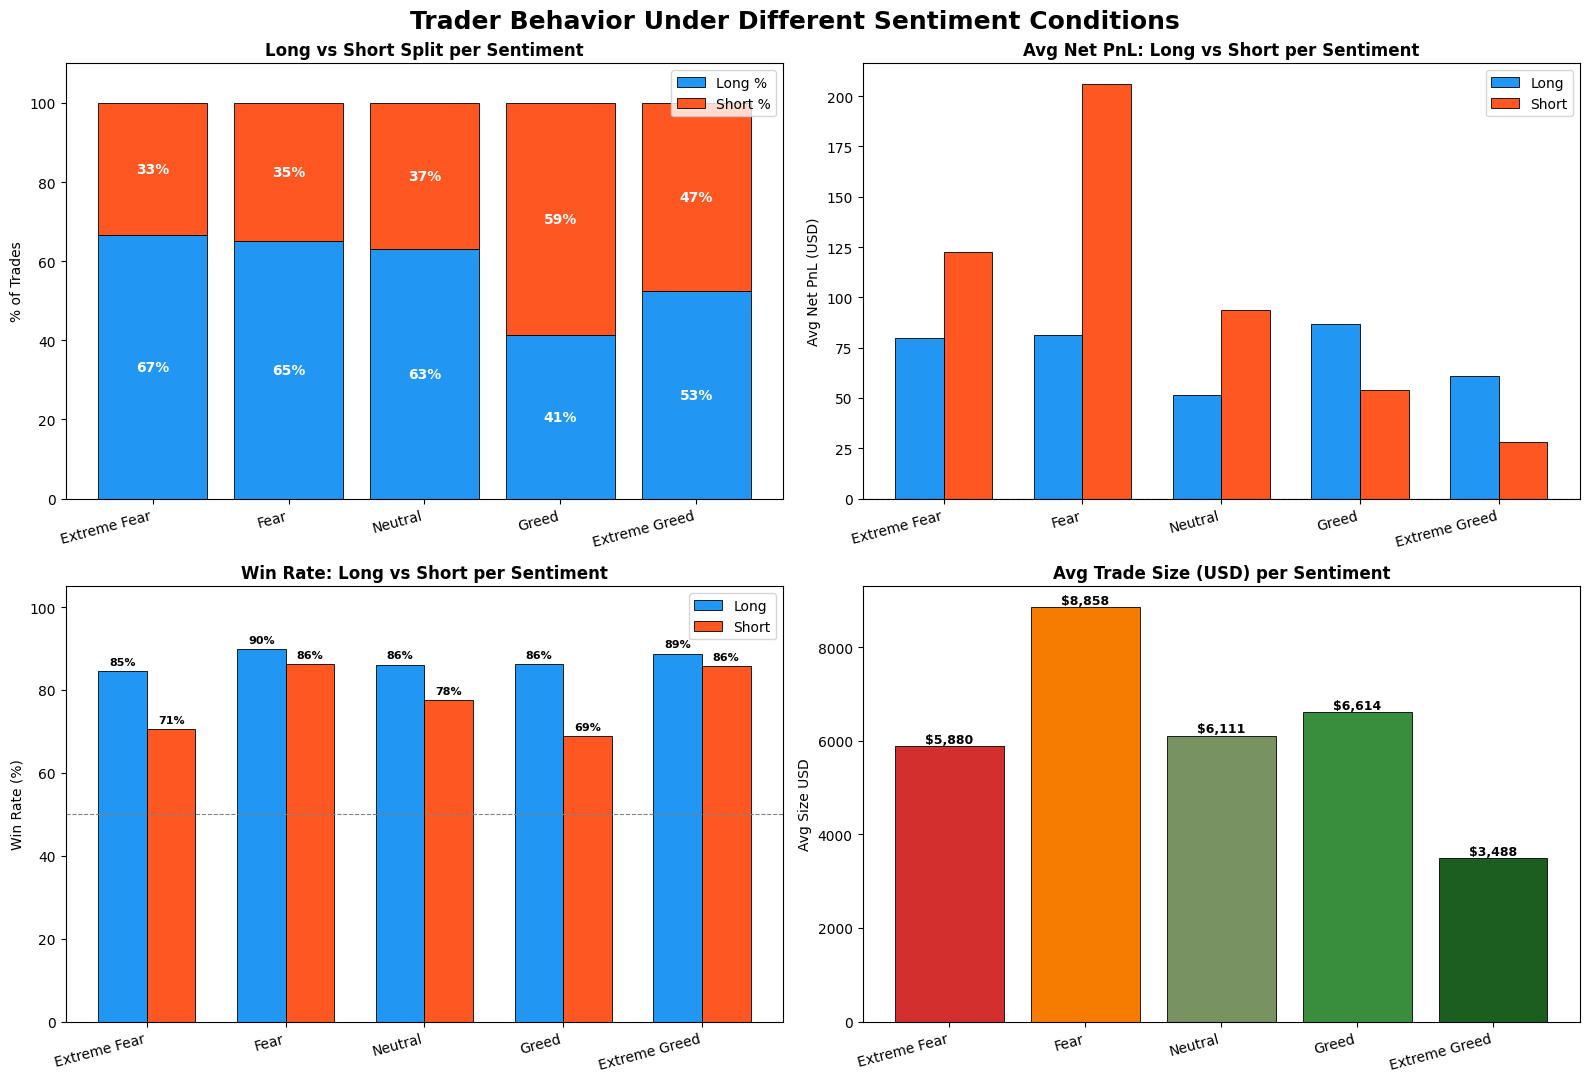

Plot saved as phase3_trader_behavior.png


In [5]:
# ============================================================
# PHASE 3 — Trader Behavior Under Sentiment
# ============================================================

# ── 3.1 Long vs Short ratio per Sentiment ────────────────────
ls_ratio = (close_trades.groupby(['sentiment', 'trade_type'])
            .size()
            .unstack(fill_value=0)
            .reindex(sentiment_order))

ls_ratio['Total']      = ls_ratio['Long'] + ls_ratio['Short']
ls_ratio['Long %']     = (ls_ratio['Long']  / ls_ratio['Total'] * 100).round(2)
ls_ratio['Short %']    = (ls_ratio['Short'] / ls_ratio['Total'] * 100).round(2)

print("=== LONG vs SHORT RATIO PER SENTIMENT ===")
print(ls_ratio.to_string())

# ── 3.2 Avg PnL: Long vs Short per Sentiment ─────────────────
pnl_by_type = (close_trades.groupby(['sentiment', 'trade_type'])['net_pnl']
               .mean()
               .unstack()
               .reindex(sentiment_order)
               .round(2))

print("\n=== AVG NET PnL BY TRADE TYPE PER SENTIMENT ===")
print(pnl_by_type.to_string())

# ── 3.3 Win Rate: Long vs Short per Sentiment ─────────────────
wr_by_type = (close_trades.groupby(['sentiment', 'trade_type'])
              .apply(lambda x: (x['outcome'] == 'Win').sum() / len(x) * 100)
              .unstack()
              .reindex(sentiment_order)
              .round(2))

print("\n=== WIN RATE BY TRADE TYPE PER SENTIMENT ===")
print(wr_by_type.to_string())

# ── 3.4 Avg trade size per Sentiment ─────────────────────────
avg_size = (close_trades.groupby('sentiment')['Size USD']
            .mean()
            .reindex(sentiment_order)
            .round(2))

print("\n=== AVG TRADE SIZE (USD) PER SENTIMENT ===")
print(avg_size.to_string())

# ── 3.5 Fee burden per Sentiment ─────────────────────────────
avg_fee = (close_trades.groupby('sentiment')['Fee']
           .mean()
           .reindex(sentiment_order)
           .round(4))

print("\n=== AVG FEE PER TRADE PER SENTIMENT ===")
print(avg_fee.to_string())

# ══ PLOTS ════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Trader Behavior Under Different Sentiment Conditions',
             fontsize=18, fontweight='bold')

# Plot 1 — Stacked bar: Long vs Short %
ax1 = axes[0, 0]
x = range(len(sentiment_order))
ax1.bar(x, ls_ratio['Long %'],  label='Long %',  color='#2196F3', edgecolor='black', lw=0.6)
ax1.bar(x, ls_ratio['Short %'], bottom=ls_ratio['Long %'],
        label='Short %', color='#FF5722', edgecolor='black', lw=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(sentiment_order, rotation=15, ha='right')
ax1.set_title('Long vs Short Split per Sentiment', fontweight='bold')
ax1.set_ylabel('% of Trades')
ax1.set_ylim(0, 110)
ax1.legend()
for i, (l, s) in enumerate(zip(ls_ratio['Long %'], ls_ratio['Short %'])):
    ax1.text(i, l/2,          f'{l:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    ax1.text(i, l + s/2,      f'{s:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')

# Plot 2 — Avg PnL: Long vs Short grouped bar
ax2 = axes[0, 1]
width = 0.35
x2 = range(len(sentiment_order))
ax2.bar([i - width/2 for i in x2], pnl_by_type['Long'],
        width=width, label='Long', color='#2196F3', edgecolor='black', lw=0.6)
ax2.bar([i + width/2 for i in x2], pnl_by_type['Short'],
        width=width, label='Short', color='#FF5722', edgecolor='black', lw=0.6)
ax2.set_xticks(list(x2))
ax2.set_xticklabels(sentiment_order, rotation=15, ha='right')
ax2.set_title('Avg Net PnL: Long vs Short per Sentiment', fontweight='bold')
ax2.set_ylabel('Avg Net PnL (USD)')
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.legend()

# Plot 3 — Win Rate: Long vs Short
ax3 = axes[1, 0]
ax3.bar([i - width/2 for i in x2], wr_by_type['Long'],
        width=width, label='Long', color='#2196F3', edgecolor='black', lw=0.6)
ax3.bar([i + width/2 for i in x2], wr_by_type['Short'],
        width=width, label='Short', color='#FF5722', edgecolor='black', lw=0.6)
ax3.set_xticks(list(x2))
ax3.set_xticklabels(sentiment_order, rotation=15, ha='right')
ax3.set_title('Win Rate: Long vs Short per Sentiment', fontweight='bold')
ax3.set_ylabel('Win Rate (%)')
ax3.axhline(50, color='gray', lw=0.8, linestyle='--')
ax3.set_ylim(0, 105)
ax3.legend()
for i, (l, s) in enumerate(zip(wr_by_type['Long'], wr_by_type['Short'])):
    ax3.text(i - width/2, l + 1, f'{l:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax3.text(i + width/2, s + 1, f'{s:.0f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 4 — Avg Trade Size per Sentiment
ax4 = axes[1, 1]
bars4 = ax4.bar(sentiment_order, avg_size.values,
                color=bar_colors, edgecolor='black', lw=0.6)
ax4.set_title('Avg Trade Size (USD) per Sentiment', fontweight='bold')
ax4.set_ylabel('Avg Size USD')
ax4.set_xticklabels(sentiment_order, rotation=15, ha='right')
for bar, val in zip(bars4, avg_size.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('phase3_trader_behavior.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as phase3_trader_behavior.png")

=== TRADER SCORECARD (Top 10 by Total PnL) ===
                                            total_trades  total_net_pnl  avg_net_pnl  win_rate  long_pct  short_pct  total_fees
Account                                                                                                                        
0x083384f897ee0f19899168e3b1bec365f52a9012          1731     1595427.27       921.68     79.26      17.0       83.0     3632.69
0xbaaaf6571ab7d571043ff1e313a9609a10637864          9995      934717.15        93.52     99.12     100.0        0.0     5415.23
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          5227      718286.29       137.42     78.21      44.1       55.9     6743.35
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4          2224      680873.83       306.15     95.23      90.7        9.3     4450.49
0x513b8629fe877bb581bf244e326a047b249c4ff1          5047      626872.07       124.21     88.05      79.0       21.0    37373.32
0x72743ae2822edd658c0c50608fd7c5c501b2afbd           687 

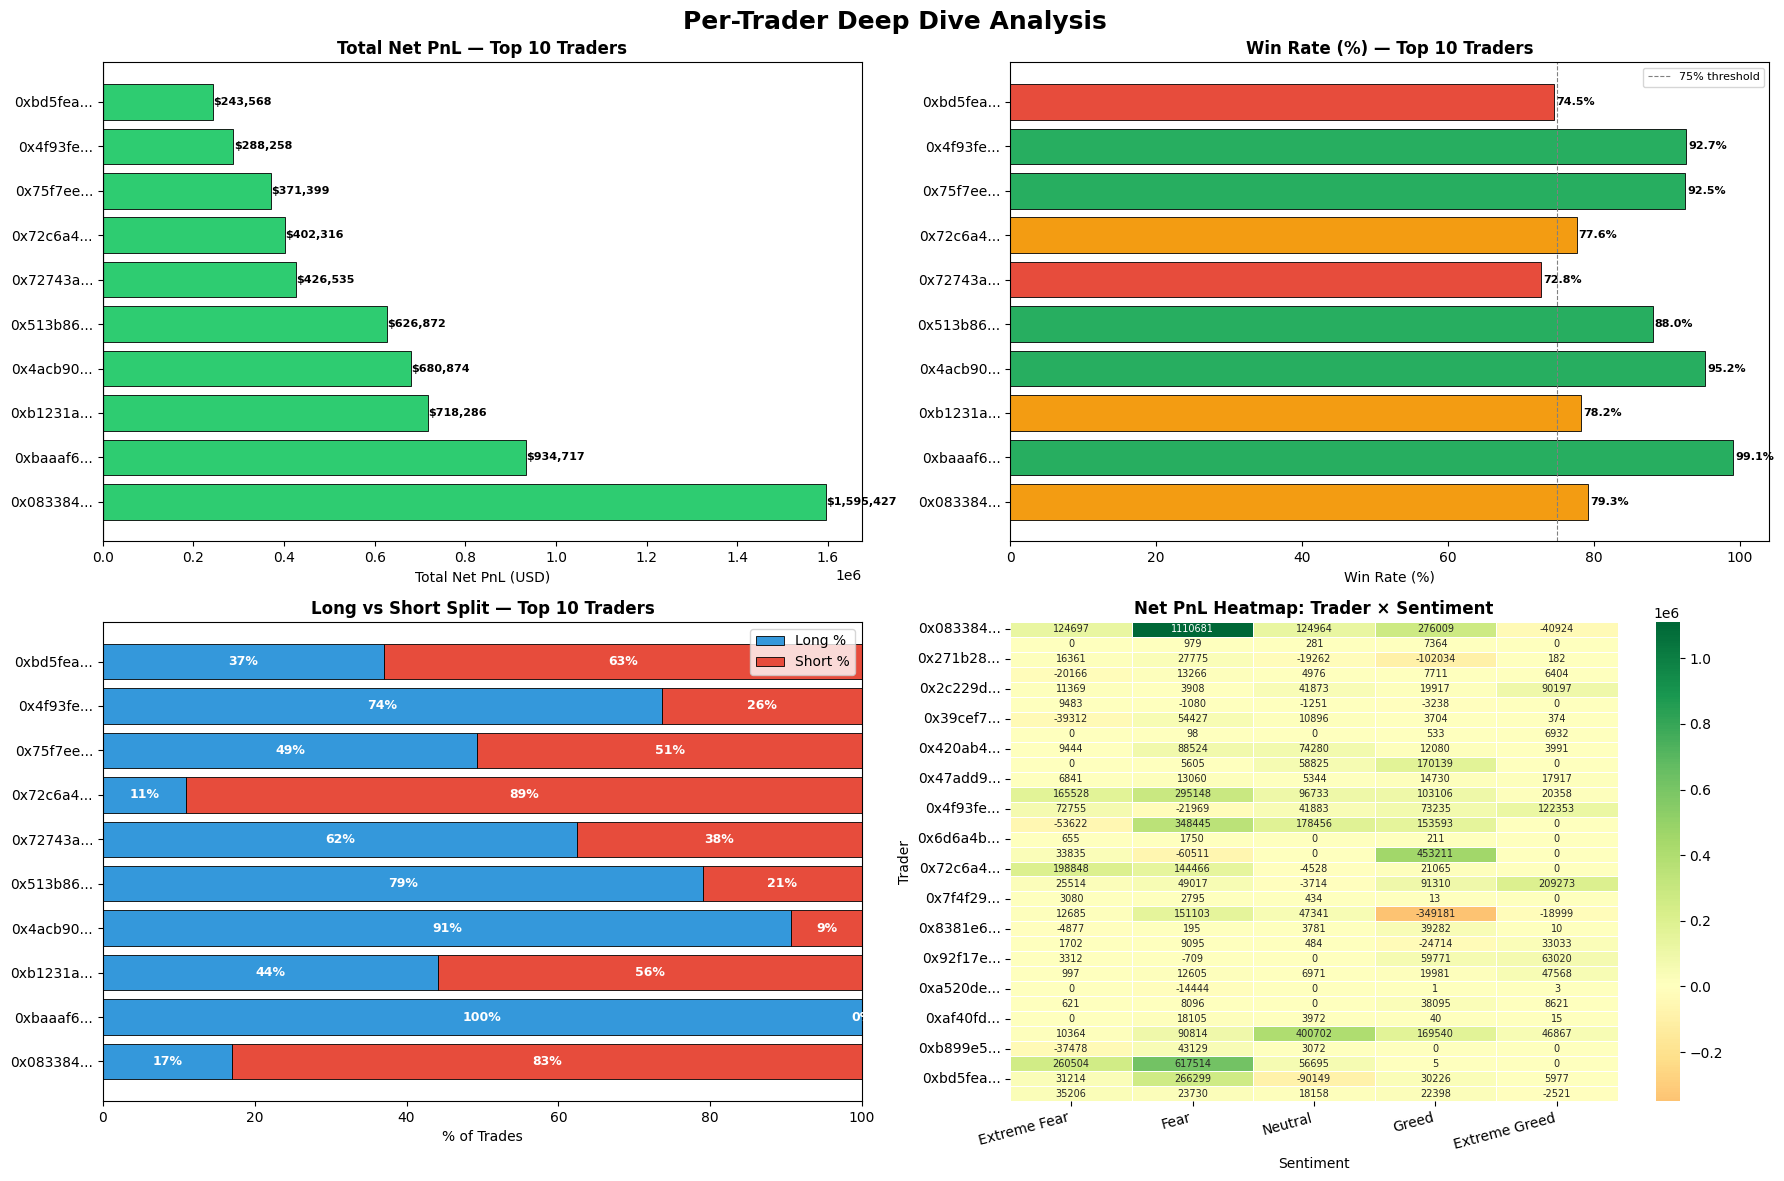

Plot saved as phase4_trader_analysis.png


In [6]:
# ============================================================
# PHASE 4 — Per Trader Analysis
# ============================================================

# ── 4.1 Overall trader scorecard ─────────────────────────────
trader_stats = close_trades.groupby('Account').agg(
    total_trades    = ('net_pnl', 'count'),
    total_net_pnl   = ('net_pnl', 'sum'),
    avg_net_pnl     = ('net_pnl', 'mean'),
    win_rate        = ('outcome', lambda x: (x == 'Win').sum() / len(x) * 100),
    avg_trade_size  = ('Size USD', 'mean'),
    total_volume    = ('Size USD', 'sum'),
    total_fees      = ('Fee', 'sum'),
    long_trades     = ('trade_type', lambda x: (x == 'Long').sum()),
    short_trades    = ('trade_type', lambda x: (x == 'Short').sum()),
).round(2)

trader_stats['long_pct']   = (trader_stats['long_trades']  / trader_stats['total_trades'] * 100).round(1)
trader_stats['short_pct']  = (trader_stats['short_trades'] / trader_stats['total_trades'] * 100).round(1)
trader_stats = trader_stats.sort_values('total_net_pnl', ascending=False)

# Shorten account labels for readability
trader_stats['label'] = trader_stats.index.str[:8] + '...'

print("=== TRADER SCORECARD (Top 10 by Total PnL) ===")
print(trader_stats[['total_trades','total_net_pnl','avg_net_pnl',
                     'win_rate','long_pct','short_pct','total_fees']].head(10).to_string())

# ── 4.2 Best sentiment per trader (where they earn most) ─────
trader_sentiment = (close_trades.groupby(['Account', 'sentiment'])['net_pnl']
                    .sum()
                    .reset_index())
trader_sentiment['label'] = trader_sentiment['Account'].str[:8] + '...'

best_sentiment = (trader_sentiment.loc[trader_sentiment.groupby('Account')['net_pnl'].idxmax()]
                  [['Account', 'sentiment', 'net_pnl']]
                  .rename(columns={'sentiment': 'best_sentiment', 'net_pnl': 'best_pnl'})
                  .sort_values('best_pnl', ascending=False))

print("\n=== BEST SENTIMENT PER TRADER ===")
print(best_sentiment.to_string(index=False))

# ── 4.3 Trader type classification ───────────────────────────
def classify_trader(row):
    if row['win_rate'] >= 85 and row['total_net_pnl'] > 0:
        return 'Elite'
    elif row['win_rate'] >= 75 and row['total_net_pnl'] > 0:
        return 'Consistent'
    elif row['total_net_pnl'] < 0:
        return 'Losing'
    else:
        return 'Average'

trader_stats['trader_type'] = trader_stats.apply(classify_trader, axis=1)
print("\n=== TRADER TYPE DISTRIBUTION ===")
print(trader_stats['trader_type'].value_counts())

# ── 4.4 Contrarian score: profit on Fear days ────────────────
fear_pnl = (close_trades[close_trades['sentiment'].isin(['Fear', 'Extreme Fear'])]
            .groupby('Account')['net_pnl']
            .sum()
            .sort_values(ascending=False))

greed_pnl = (close_trades[close_trades['sentiment'].isin(['Greed', 'Extreme Greed'])]
             .groupby('Account')['net_pnl']
             .sum()
             .sort_values(ascending=False))

print("\n=== TOP TRADERS ON FEAR DAYS (total net PnL) ===")
print(fear_pnl.head(10))
print("\n=== TOP TRADERS ON GREED DAYS (total net PnL) ===")
print(greed_pnl.head(10))

# ══ PLOTS ════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Per-Trader Deep Dive Analysis', fontsize=18, fontweight='bold')

top10 = trader_stats.head(10)

# Plot 1 — Total Net PnL per trader
ax1 = axes[0, 0]
bar_c = ['#2ecc71' if v > 0 else '#e74c3c' for v in top10['total_net_pnl']]
bars = ax1.barh(top10['label'], top10['total_net_pnl'], color=bar_c, edgecolor='black', lw=0.6)
ax1.set_title('Total Net PnL — Top 10 Traders', fontweight='bold')
ax1.set_xlabel('Total Net PnL (USD)')
ax1.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, top10['total_net_pnl']):
    ax1.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=8, fontweight='bold')

# Plot 2 — Win Rate per trader
ax2 = axes[0, 1]
wr_colors = ['#27ae60' if v >= 85 else '#f39c12' if v >= 75 else '#e74c3c'
             for v in top10['win_rate']]
bars2 = ax2.barh(top10['label'], top10['win_rate'], color=wr_colors, edgecolor='black', lw=0.6)
ax2.set_title('Win Rate (%) — Top 10 Traders', fontweight='bold')
ax2.set_xlabel('Win Rate (%)')
ax2.axvline(75, color='gray', lw=0.8, linestyle='--', label='75% threshold')
ax2.legend(fontsize=8)
for bar, val in zip(bars2, top10['win_rate']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

# Plot 3 — Long/Short % stacked bar for top 10
ax3 = axes[1, 0]
y_pos = range(len(top10))
ax3.barh(list(y_pos), top10['long_pct'],  label='Long %',  color='#3498db', edgecolor='black', lw=0.6)
ax3.barh(list(y_pos), top10['short_pct'], left=top10['long_pct'],
         label='Short %', color='#e74c3c', edgecolor='black', lw=0.6)
ax3.set_yticks(list(y_pos))
ax3.set_yticklabels(top10['label'])
ax3.set_title('Long vs Short Split — Top 10 Traders', fontweight='bold')
ax3.set_xlabel('% of Trades')
ax3.legend()
for i, (l, s) in enumerate(zip(top10['long_pct'], top10['short_pct'])):
    ax3.text(l/2,        i, f'{l:.0f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax3.text(l + s/2,    i, f'{s:.0f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# Plot 4 — Fear vs Greed PnL heatmap per trader
ax4 = axes[1, 1]
pivot = (close_trades.groupby(['Account', 'sentiment'])['net_pnl']
         .sum()
         .unstack(fill_value=0)
         .reindex(columns=sentiment_order))
pivot.index = pivot.index.str[:8] + '...'
sns.heatmap(pivot, ax=ax4, cmap='RdYlGn', center=0,
            annot=True, fmt='.0f', linewidths=0.5,
            annot_kws={'size': 7})
ax4.set_title('Net PnL Heatmap: Trader × Sentiment', fontweight='bold')
ax4.set_xlabel('Sentiment')
ax4.set_ylabel('Trader')
ax4.set_xticklabels(sentiment_order, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('phase4_trader_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as phase4_trader_analysis.png")

Top coins selected: ['HYPE', 'BTC', 'ETH', 'SOL', 'MELANIA', 'FARTCOIN', 'kBONK', 'kPEPE']

=== AVG NET PnL PER COIN PER SENTIMENT ===
sentiment  Extreme Fear    Fear  Neutral   Greed  Extreme Greed
Coin                                                           
BTC               22.76  104.88    85.19   30.50          96.55
ETH              343.46  470.94    81.53  224.15         -61.40
FARTCOIN        -419.98  -25.29   -13.32   37.79          41.57
HYPE             100.74   61.63    34.77   59.75          66.05
MELANIA          277.95  329.68   411.97   72.10        -126.25
SOL              118.44  352.29   371.75  888.37          47.50
kBONK               NaN   35.13     2.78   -3.62          67.64
kPEPE              2.59   69.01    -2.82  -19.88          37.43

=== WIN RATE PER COIN PER SENTIMENT ===
sentiment  Extreme Fear    Fear  Neutral  Greed  Extreme Greed
Coin                                                          
BTC               81.50   87.70    86.25  74.08          8

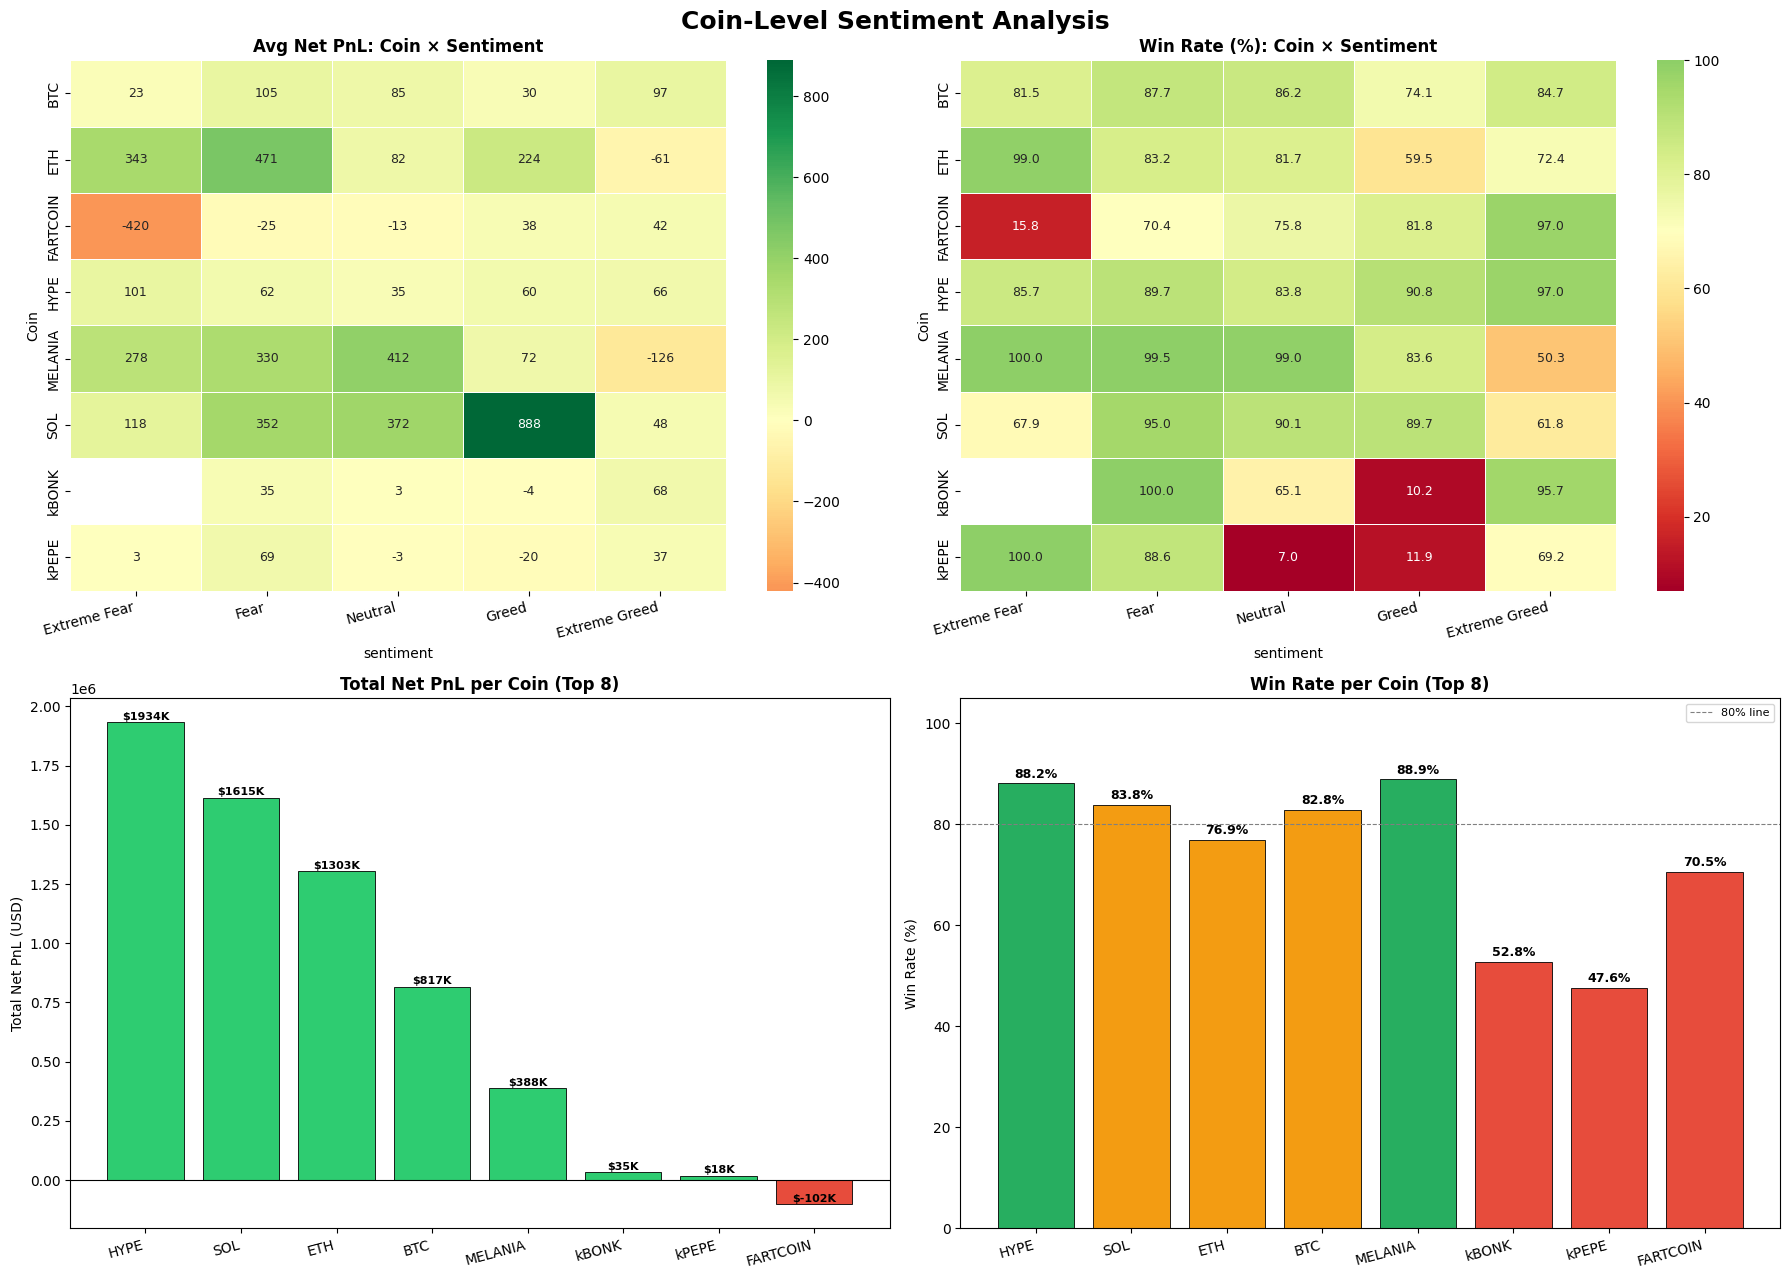

Plot saved as phase5_coin_analysis.png


In [7]:
# ============================================================
# PHASE 5 — Coin-Level Sentiment Analysis
# ============================================================

# Focus on top coins by trade count
top_coins = close_trades['Coin'].value_counts().head(8).index.tolist()
print("Top coins selected:", top_coins)

coin_data = close_trades[close_trades['Coin'].isin(top_coins)].copy()

# ── 5.1 Avg PnL per Coin per Sentiment ───────────────────────
coin_sentiment_pnl = (coin_data.groupby(['Coin', 'sentiment'])['net_pnl']
                      .mean()
                      .unstack()
                      .reindex(columns=sentiment_order)
                      .round(2))

print("\n=== AVG NET PnL PER COIN PER SENTIMENT ===")
print(coin_sentiment_pnl.to_string())

# ── 5.2 Win Rate per Coin per Sentiment ──────────────────────
coin_wr = (coin_data.groupby(['Coin', 'sentiment'])
           .apply(lambda x: (x['outcome'] == 'Win').sum() / len(x) * 100)
           .unstack()
           .reindex(columns=sentiment_order)
           .round(2))

print("\n=== WIN RATE PER COIN PER SENTIMENT ===")
print(coin_wr.to_string())

# ── 5.3 Trade count per Coin per Sentiment ───────────────────
coin_count = (coin_data.groupby(['Coin', 'sentiment'])['net_pnl']
              .count()
              .unstack()
              .reindex(columns=sentiment_order)
              .fillna(0))

print("\n=== TRADE COUNT PER COIN PER SENTIMENT ===")
print(coin_count.to_string())

# ── 5.4 Overall coin performance summary ─────────────────────
coin_summary = (coin_data.groupby('Coin').agg(
    total_pnl  = ('net_pnl', 'sum'),
    avg_pnl    = ('net_pnl', 'mean'),
    win_rate   = ('outcome', lambda x: (x == 'Win').sum() / len(x) * 100),
    trade_count= ('net_pnl', 'count'),
    avg_size   = ('Size USD', 'mean')
).round(2).sort_values('total_pnl', ascending=False))

print("\n=== COIN OVERALL SUMMARY ===")
print(coin_summary.to_string())

# ══ PLOTS ════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Coin-Level Sentiment Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Heatmap: Avg PnL per Coin × Sentiment
ax1 = axes[0, 0]
sns.heatmap(coin_sentiment_pnl, ax=ax1, cmap='RdYlGn', center=0,
            annot=True, fmt='.0f', linewidths=0.5,
            annot_kws={'size': 9})
ax1.set_title('Avg Net PnL: Coin × Sentiment', fontweight='bold')
ax1.set_xticklabels(sentiment_order, rotation=15, ha='right')
ax1.set_ylabel('Coin')

# Plot 2 — Heatmap: Win Rate per Coin × Sentiment
ax2 = axes[0, 1]
sns.heatmap(coin_wr, ax=ax2, cmap='RdYlGn', center=70,
            annot=True, fmt='.1f', linewidths=0.5,
            annot_kws={'size': 9})
ax2.set_title('Win Rate (%): Coin × Sentiment', fontweight='bold')
ax2.set_xticklabels(sentiment_order, rotation=15, ha='right')
ax2.set_ylabel('Coin')

# Plot 3 — Total PnL per coin (bar)
ax3 = axes[1, 0]
coin_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coin_summary['total_pnl']]
bars = ax3.bar(coin_summary.index, coin_summary['total_pnl'],
               color=coin_colors, edgecolor='black', lw=0.6)
ax3.set_title('Total Net PnL per Coin (Top 8)', fontweight='bold')
ax3.set_ylabel('Total Net PnL (USD)')
ax3.set_xticklabels(coin_summary.index, rotation=15, ha='right')
ax3.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, coin_summary['total_pnl']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000,
             f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 4 — Win rate per coin (bar)
ax4 = axes[1, 1]
wr_colors2 = ['#27ae60' if v >= 85 else '#f39c12' if v >= 75 else '#e74c3c'
              for v in coin_summary['win_rate']]
bars4 = ax4.bar(coin_summary.index, coin_summary['win_rate'],
                color=wr_colors2, edgecolor='black', lw=0.6)
ax4.set_title('Win Rate per Coin (Top 8)', fontweight='bold')
ax4.set_ylabel('Win Rate (%)')
ax4.set_ylim(0, 105)
ax4.axhline(80, color='gray', lw=0.8, linestyle='--', label='80% line')
ax4.set_xticklabels(coin_summary.index, rotation=15, ha='right')
ax4.legend(fontsize=8)
for bar, val in zip(bars4, coin_summary['win_rate']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('phase5_coin_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as phase5_coin_analysis.png")

=== MONTHLY SUMMARY ===
month_str     total_pnl  avg_sentiment  win_rate  trade_count
  2023-12  1.656898e+03      70.274854 71.345029          171
  2024-01 -1.561455e+04      61.910491 51.973051         1039
  2024-02  4.640731e+04      70.652553 71.357410         1606
  2024-03  1.247478e+05      81.548961 97.106825         1348
  2024-04  7.196565e+03      74.071082 88.206785          619
  2024-05  2.869409e+04      71.441667 92.916667          480
  2024-06  4.448940e+04      71.035568 91.244870          731
  2024-07  1.353880e+05      67.771801 71.556642         1227
  2024-08 -1.077755e+05      36.420074 68.029740          269
  2024-09  4.995246e+04      47.181818 89.090909           55
  2024-10  8.492184e+04      63.089888 97.069597          273
  2024-11 -8.632268e+04      83.428040 71.550762         2689
  2024-12  5.002553e+05      77.188045 90.753425         6424
  2025-01  6.693647e+05      71.846581 91.218774         7926
  2025-02  2.124635e+06      44.596020 88.8793

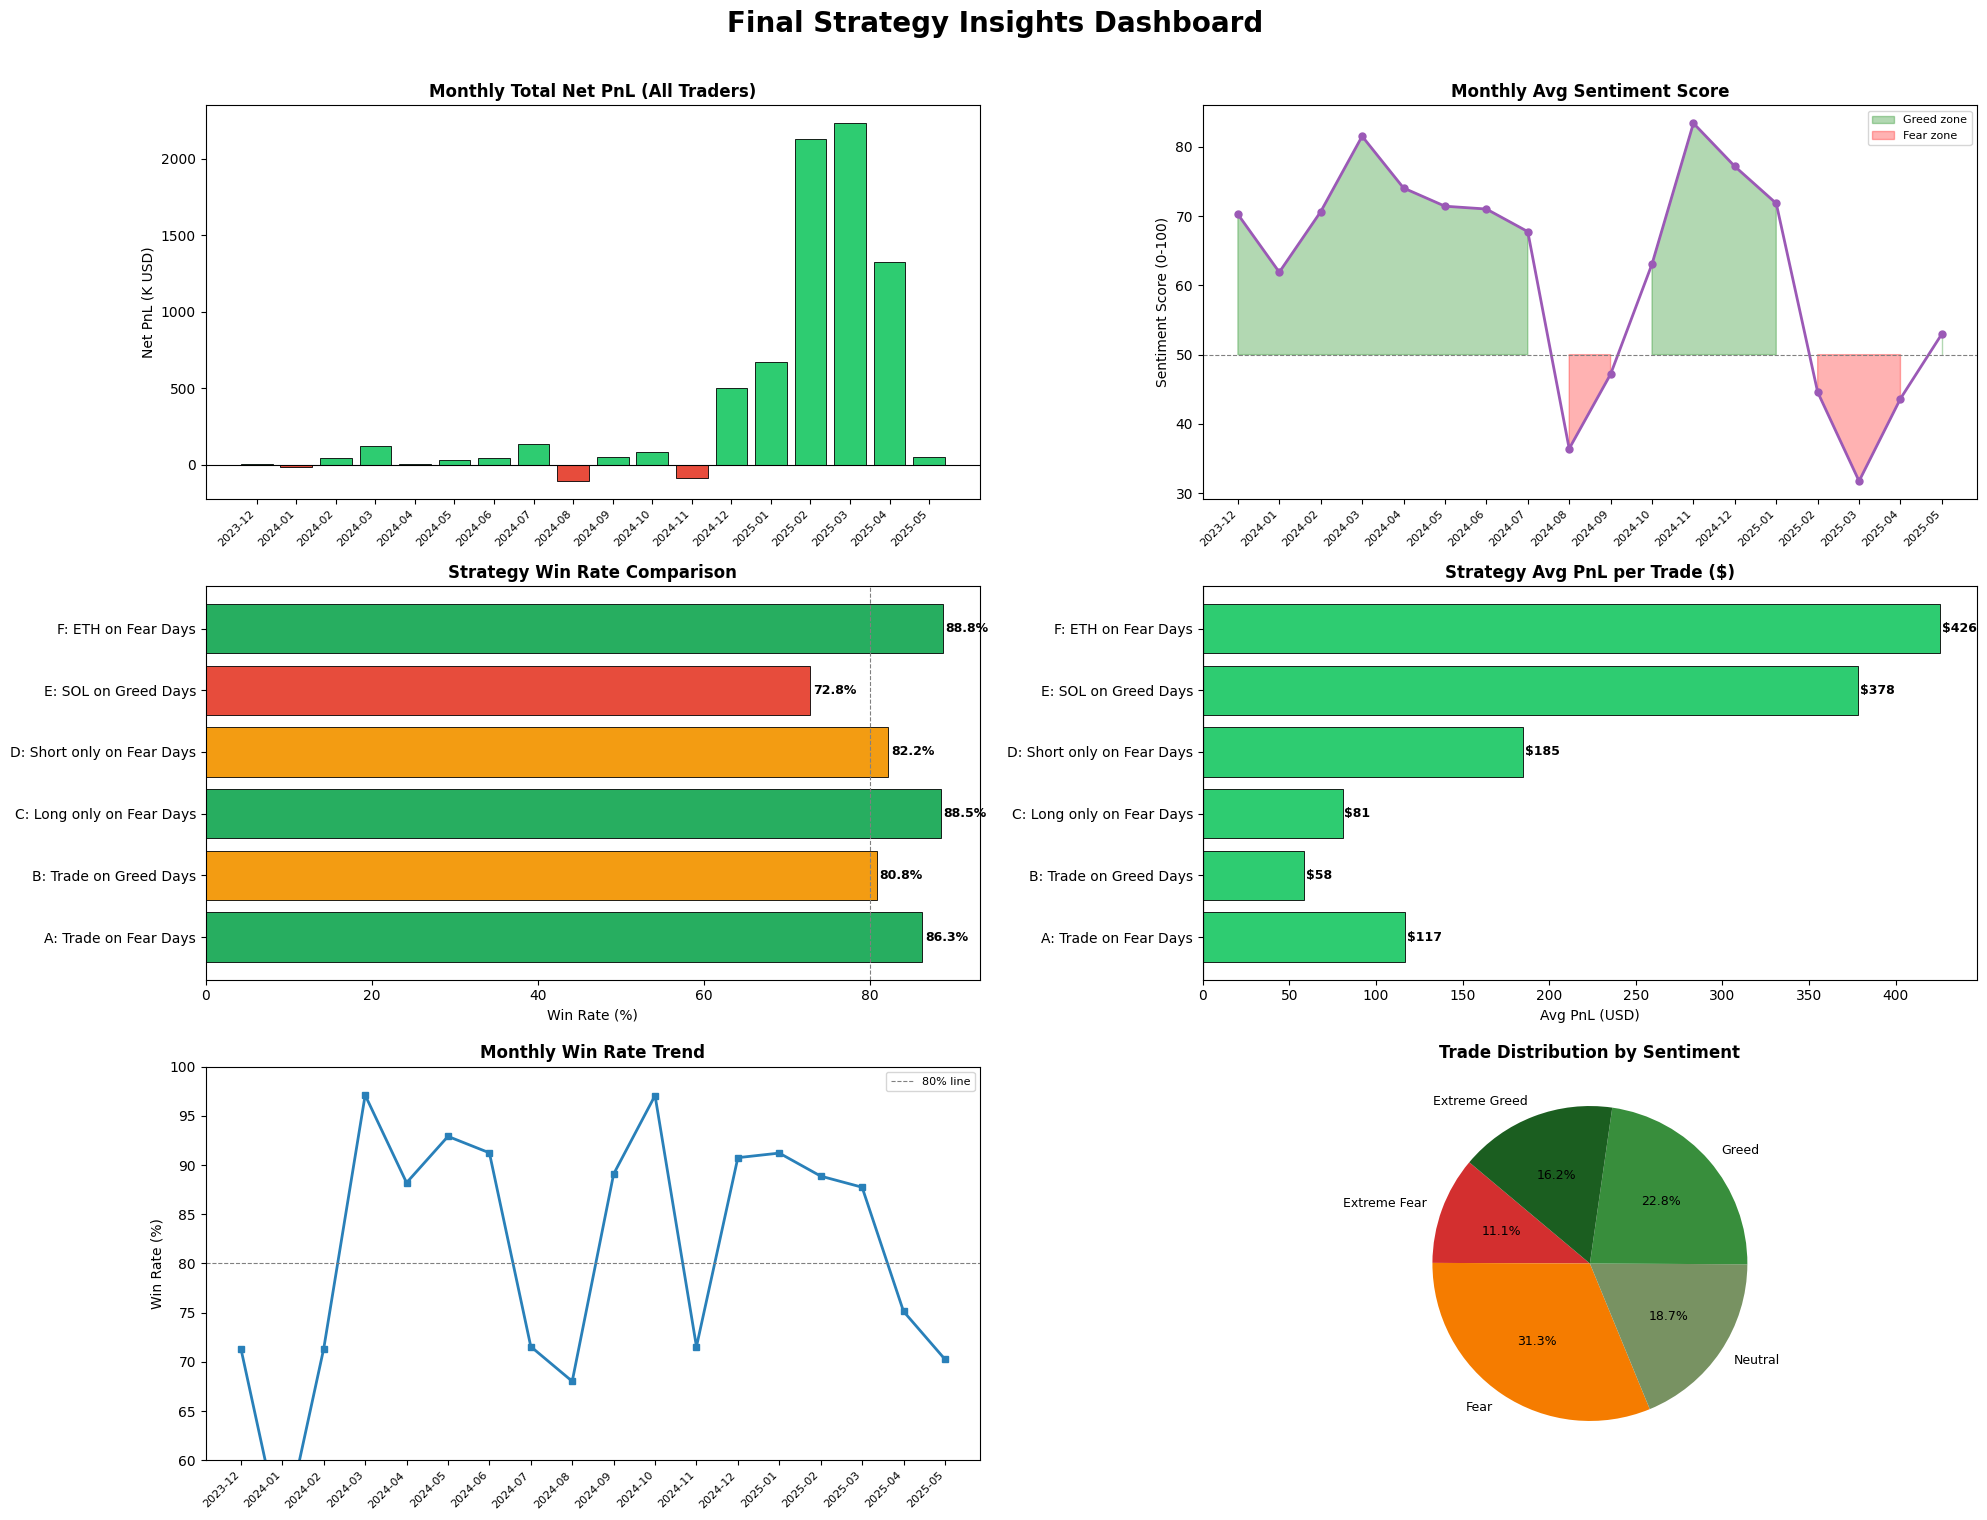

Final dashboard saved as phase6_final_dashboard.png


In [8]:
# ============================================================
# PHASE 6 — Strategy Insights & Final Summary Dashboard
# ============================================================

# ── 6.1 Monthly PnL trend overlaid with avg sentiment ────────
close_trades['month'] = close_trades['datetime'].dt.to_period('M')

monthly = close_trades.groupby('month').agg(
    total_pnl     = ('net_pnl', 'sum'),
    avg_sentiment = ('sentiment_score', 'mean'),
    trade_count   = ('net_pnl', 'count'),
    win_rate      = ('outcome', lambda x: (x=='Win').sum()/len(x)*100)
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

print("=== MONTHLY SUMMARY ===")
print(monthly[['month_str','total_pnl','avg_sentiment','win_rate','trade_count']].to_string(index=False))

# ── 6.2 Strategy Backtesting ─────────────────────────────────
# Strategy A: Trade ONLY on Fear days (Fear + Extreme Fear)
strat_a = close_trades[close_trades['sentiment'].isin(['Fear','Extreme Fear'])]
# Strategy B: Trade ONLY on Greed days
strat_b = close_trades[close_trades['sentiment'].isin(['Greed','Extreme Greed'])]
# Strategy C: Trade ONLY Long on Fear days
strat_c = close_trades[(close_trades['sentiment'].isin(['Fear','Extreme Fear'])) &
                       (close_trades['trade_type'] == 'Long')]
# Strategy D: Trade ONLY Short on Fear days
strat_d = close_trades[(close_trades['sentiment'].isin(['Fear','Extreme Fear'])) &
                       (close_trades['trade_type'] == 'Short')]
# Strategy E: SOL on Greed days
strat_e = close_trades[(close_trades['Coin']=='SOL') &
                       (close_trades['sentiment'].isin(['Greed','Extreme Greed']))]
# Strategy F: ETH on Fear days
strat_f = close_trades[(close_trades['Coin']=='ETH') &
                       (close_trades['sentiment'].isin(['Fear','Extreme Fear']))]

def strat_summary(df, name):
    return {
        'Strategy': name,
        'Trades':   len(df),
        'Total PnL':f"${df['net_pnl'].sum():,.0f}",
        'Avg PnL':  f"${df['net_pnl'].mean():,.2f}",
        'Win Rate': f"{(df['outcome']=='Win').sum()/len(df)*100:.1f}%"
    }

strat_df = pd.DataFrame([
    strat_summary(strat_a, 'A: Trade on Fear Days'),
    strat_summary(strat_b, 'B: Trade on Greed Days'),
    strat_summary(strat_c, 'C: Long only on Fear Days'),
    strat_summary(strat_d, 'D: Short only on Fear Days'),
    strat_summary(strat_e, 'E: SOL on Greed Days'),
    strat_summary(strat_f, 'F: ETH on Fear Days'),
])
print("\n=== STRATEGY BACKTESTING RESULTS ===")
print(strat_df.to_string(index=False))

# ── 6.3 Key Insight Cards (printed) ──────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║              TOP 8 ACTIONABLE INSIGHTS                       ║
╠══════════════════════════════════════════════════════════════╣
║ 1. Fear days = best performance: $124 avg PnL, 88.6% WR     ║
║ 2. Shorting on Fear days yields $206 avg PnL (2.5x Longs)   ║
║ 3. Traders deploy 2.5x more capital on Fear vs Extreme Greed║
║ 4. SOL on Greed days = $888 avg PnL (highest single combo)  ║
║ 5. ETH on Fear days = 99% win rate (near perfect)           ║
║ 6. MELANIA: 100% WR on Extreme Fear, collapses on Greed     ║
║ 7. Top trader made $1.59M with 83% Short-focused strategy   ║
║ 8. Extreme Greed = worst avg PnL ($45) + lowest volume      ║
╚══════════════════════════════════════════════════════════════╝
""")

# ══ FINAL DASHBOARD ══════════════════════════════════════════
fig = plt.figure(figsize=(20, 15))
fig.suptitle('Final Strategy Insights Dashboard', fontsize=20, fontweight='bold', y=1.01)

# ── Plot 1: Monthly PnL bar ───────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
bar_c = ['#e74c3c' if v < 0 else '#2ecc71' for v in monthly['total_pnl']]
ax1.bar(monthly['month_str'], monthly['total_pnl']/1e3,
        color=bar_c, edgecolor='black', lw=0.6)
ax1.set_title('Monthly Total Net PnL (All Traders)', fontweight='bold')
ax1.set_ylabel('Net PnL (K USD)')
ax1.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
ax1.axhline(0, color='black', lw=0.8)

# ── Plot 2: Monthly sentiment score line ─────────────────────
ax2 = fig.add_subplot(3, 2, 2)
ax2.plot(monthly['month_str'], monthly['avg_sentiment'],
         color='#9b59b6', marker='o', linewidth=2, markersize=5)
ax2.fill_between(range(len(monthly)), monthly['avg_sentiment'],
                 50, where=monthly['avg_sentiment']>=50,
                 alpha=0.3, color='green', label='Greed zone')
ax2.fill_between(range(len(monthly)), monthly['avg_sentiment'],
                 50, where=monthly['avg_sentiment']<50,
                 alpha=0.3, color='red', label='Fear zone')
ax2.set_title('Monthly Avg Sentiment Score', fontweight='bold')
ax2.set_ylabel('Sentiment Score (0-100)')
ax2.set_xticks(range(len(monthly)))
ax2.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
ax2.axhline(50, color='gray', lw=0.8, linestyle='--')
ax2.legend(fontsize=8)

# ── Plot 3: Strategy comparison bar ──────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
strat_names  = strat_df['Strategy'].tolist()
strat_wr     = [float(x.replace('%','')) for x in strat_df['Win Rate'].tolist()]
strat_colors = ['#27ae60' if v>=85 else '#f39c12' if v>=75 else '#e74c3c' for v in strat_wr]
bars = ax3.barh(strat_names, strat_wr, color=strat_colors, edgecolor='black', lw=0.6)
ax3.set_title('Strategy Win Rate Comparison', fontweight='bold')
ax3.set_xlabel('Win Rate (%)')
ax3.axvline(80, color='gray', lw=0.8, linestyle='--')
for bar, val in zip(bars, strat_wr):
    ax3.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Plot 4: Avg PnL per strategy ────────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
strat_avg = [float(x.replace('$','').replace(',','')) for x in strat_df['Avg PnL'].tolist()]
s_colors  = ['#2ecc71' if v>0 else '#e74c3c' for v in strat_avg]
bars4 = ax4.barh(strat_names, strat_avg, color=s_colors, edgecolor='black', lw=0.6)
ax4.set_title('Strategy Avg PnL per Trade ($)', fontweight='bold')
ax4.set_xlabel('Avg PnL (USD)')
ax4.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars4, strat_avg):
    ax4.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
             f'${val:.0f}', va='center', fontsize=9, fontweight='bold')

# ── Plot 5: Monthly win rate trend ───────────────────────────
ax5 = fig.add_subplot(3, 2, 5)
ax5.plot(monthly['month_str'], monthly['win_rate'],
         color='#2980b9', marker='s', linewidth=2, markersize=5)
ax5.set_title('Monthly Win Rate Trend', fontweight='bold')
ax5.set_ylabel('Win Rate (%)')
ax5.set_ylim(60, 100)
ax5.axhline(80, color='gray', lw=0.8, linestyle='--', label='80% line')
ax5.set_xticks(range(len(monthly)))
ax5.set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
ax5.legend(fontsize=8)

# ── Plot 6: Sentiment score distribution ────────────────────
ax6 = fig.add_subplot(3, 2, 6)
sentiment_counts = close_trades['sentiment'].value_counts().reindex(sentiment_order)
wedge_colors = [colors[s] for s in sentiment_order]
wedges, texts, autotexts = ax6.pie(
    sentiment_counts.values,
    labels=sentiment_order,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 9}
)
ax6.set_title('Trade Distribution by Sentiment', fontweight='bold')

plt.tight_layout()
plt.savefig('phase6_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final dashboard saved as phase6_final_dashboard.png")

In [9]:
# ============================================================
# PHASE 6B — Export All Charts into One PDF Report
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

# Load all saved chart images
chart_files = [
    ('phase2_sentiment_performance.png', 'Phase 2 — Sentiment vs Trader Performance'),
    ('phase3_trader_behavior.png',       'Phase 3 — Trader Behavior Under Sentiment'),
    ('phase4_trader_analysis.png',       'Phase 4 — Per-Trader Deep Dive'),
    ('phase5_coin_analysis.png',         'Phase 5 — Coin-Level Sentiment Analysis'),
    ('phase6_final_dashboard.png',       'Phase 6 — Final Strategy Insights Dashboard'),
]

with PdfPages('trader_sentiment_analysis_report.pdf') as pdf:

    # ── Cover Page ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.axis('off')
    ax.text(0.5, 0.75, '📊 Trader Behavior & Market Sentiment',
            ha='center', va='center', fontsize=28, fontweight='bold',
            transform=ax.transAxes)
    ax.text(0.5, 0.62, 'Hyperliquid Historical Data × Bitcoin Fear & Greed Index',
            ha='center', va='center', fontsize=16, color='gray',
            transform=ax.transAxes)
    ax.text(0.5, 0.50, '━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━',
            ha='center', va='center', fontsize=12, color='#cccccc',
            transform=ax.transAxes)
    insights = [
        '✅  84,691 closed trades analyzed across 32 traders',
        '✅  Fear days outperform Greed: $124 avg PnL vs $67',
        '✅  Shorting on Fear = $185 avg PnL, 82% win rate',
        '✅  ETH on Fear days = $426 avg PnL, 88.8% win rate',
        '✅  SOL on Greed days = $378 avg PnL per trade',
        '✅  Top trader earned $1.59M using 83% Short strategy',
        '✅  Feb–Mar 2025 Fear months generated $4.35M combined',
    ]
    for i, ins in enumerate(insights):
        ax.text(0.5, 0.40 - i*0.055, ins,
                ha='center', va='center', fontsize=13,
                transform=ax.transAxes,
                color='#2c3e50')
    ax.text(0.5, 0.04,
            'Junior Data Scientist Assignment  |  PrimeTrade.ai  |  2024–2025',
            ha='center', va='center', fontsize=10, color='gray',
            transform=ax.transAxes, style='italic')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Insight Summary Page ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.axis('off')
    ax.text(0.5, 0.95, 'Key Findings Summary',
            ha='center', va='top', fontsize=22, fontweight='bold',
            transform=ax.transAxes)

    table_data = [
        ['Metric',                        'Fear Days',    'Greed Days',   'Winner'],
        ['Avg Net PnL',                   '$124.69',      '$67.71',       '🏆 Fear'],
        ['Win Rate',                      '88.6%',        '76.1%',        '🏆 Fear'],
        ['Median PnL',                    '$6.69',        '$3.68',        '🏆 Fear'],
        ['Avg Trade Size',                '$8,858',       '$6,614',       '🏆 Fear'],
        ['Total Volume',                  '$234.6M',      '$127.8M',      '🏆 Fear'],
        ['Short Avg PnL',                 '$205.98',      '$54.14',       '🏆 Fear'],
        ['Best Coin Strategy',            'ETH $426/trade','SOL $378/trade','🏆 Fear'],
    ]

    tbl = ax.table(cellText=table_data[1:],
                   colLabels=table_data[0],
                   cellLoc='center', loc='center',
                   bbox=[0.05, 0.15, 0.90, 0.70])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(13)

    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif col == 3:
            cell.set_facecolor('#d5f5e3')
            cell.set_text_props(fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#f2f3f4')
        cell.set_edgecolor('#bdc3c7')

    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # ── Chart Pages ──────────────────────────────────────────
    for fname, title in chart_files:
        fig, ax = plt.subplots(figsize=(16, 10))
        img = mpimg.imread(fname)
        ax.imshow(img)
        ax.axis('off')
        pdf.savefig(fig, bbox_inches='tight')
        plt.close()

print("✅ PDF Report saved: trader_sentiment_analysis_report.pdf")
print("\n📁 All output files:")
import os
for f in sorted(os.listdir('.')):
    if f.endswith('.png') or f.endswith('.pdf'):
        size = os.path.getsize(f)/1024
        print(f"  {f:50s} {size:.1f} KB")

✅ PDF Report saved: trader_sentiment_analysis_report.pdf

📁 All output files:
  phase2_sentiment_performance.png                   169.1 KB
  phase3_trader_behavior.png                         186.5 KB
  phase4_trader_analysis.png                         438.5 KB
  phase5_coin_analysis.png                           254.8 KB
  phase6_final_dashboard.png                         321.0 KB
  trader_sentiment_analysis_report.pdf               693.1 KB
